<a href="https://colab.research.google.com/github/abasu0713/coder-model-gallery/blob/master/flux_schnell_lora_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flux Schnell LoRA Training

Train a LoRA on **FLUX.1-schnell** using [ostris/ai-toolkit](https://github.com/ostris/ai-toolkit) with the Schnell training adapter.

**Requirements:** Google Colab with A100 GPU (Colab Pro recommended). T4 may work with rank 8 + quantization.

**Output:** A `.safetensors` LoRA file ready to upload to Runware.

## 1. Setup

In [ ]:
# Check GPU
!nvidia-smi

Sat Mar 21 21:59:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Clone ai-toolkit and install dependencies
!git clone https://github.com/ostris/ai-toolkit.git /content/ai-toolkit
%cd /content/ai-toolkit
!git submodule update --init --recursive
!pip install -r requirements.txt

fatal: destination path '/content/ai-toolkit' already exists and is not an empty directory.
/content/ai-toolkit
  Cloning https://github.com/huggingface/diffusers (to revision 8600b4c10d67b0ce200f664204358747bd53c775) to /tmp/pip-req-build-9egsnbf1
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-9egsnbf1
  Running command git rev-parse -q --verify 'sha^8600b4c10d67b0ce200f664204358747bd53c775'
  Running command git fetch -q https://github.com/huggingface/diffusers 8600b4c10d67b0ce200f664204358747bd53c775
  Running command git checkout -q 8600b4c10d67b0ce200f664204358747bd53c775
  Resolved https://github.com/huggingface/diffusers to commit 8600b4c10d67b0ce200f664204358747bd53c775
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Login to HuggingFace (needed for gated models)
from huggingface_hub import login

# Paste your HF token here or use Colab secrets
login()

## 2. Prepare Dataset

Upload your training images to `/content/dataset/`. Each image needs a matching `.txt` caption file.

Example:
```
/content/dataset/
  photo_01.jpg
  photo_01.txt  -> "alphaduriendur, a man with short dark hair, wearing a blue shirt, indoor lighting"
  photo_02.jpg
  photo_02.txt  -> "alphaduriendur, a man smiling, outdoor natural light, casual clothing"
```

**Tips:**
- Use the trigger word `alphaduriendur` at the start of every caption
- Describe clothing, expression, lighting, and background
- 15-60 images works well, more is better up to a point
- Clear, well-lit photos with varied poses and backgrounds

In [ ]:
import os
os.makedirs("/content/dataset", exist_ok=True)

# Option A: Upload from Google Drive
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/drive/MyDrive/avatar-images/* /content/dataset/

# Option B: Upload via Colab file picker
# from google.colab import files
# uploaded = files.upload()  # then move to /content/dataset/

# Option C: Download from HuggingFace (if you've uploaded them there)
# !huggingface-cli download alphaduriendur/avatar-training-images --local-dir /content/dataset

# Verify dataset
images = [f for f in os.listdir("/content/dataset") if f.lower().endswith((".jpg", ".jpeg", ".png"))]
captions = [f for f in os.listdir("/content/dataset") if f.endswith(".txt")]
print(f"Images: {len(images)}, Captions: {len(captions)}")
assert len(images) > 0, "No images found! Upload your training images first."
assert len(images) == len(captions), f"Mismatch: {len(images)} images but {len(captions)} captions"

Mounted at /content/drive
Images: 15, Captions: 15


## 3. Training Config

Key differences from Flux Dev training:
- Uses `ostris/FLUX.1-schnell-training-adapter` (only during training, not inference)
- `guidance_scale: 1` (Schnell doesn't use classifier-free guidance)
- `sample_steps: 4` (Schnell is designed for 1-4 steps)
- Apache 2.0 license (vs Dev's non-commercial license)

In [ ]:
# Training parameters - adjust these as needed
TRIGGER_WORD = "alphaduriendur"
TRAINING_STEPS = 2500        # 500-4000, adjust based on dataset size
LORA_RANK = 16               # 8 for T4 (saves VRAM), 16 for A100
LEARNING_RATE = 1e-4
RESOLUTION = 1024
BATCH_SIZE = 1
SAVE_EVERY_N_STEPS = 500
SAMPLE_EVERY_N_STEPS = 250   # Generate test images during training

OUTPUT_DIR = "/content/output"
DATASET_DIR = "/content/dataset"

In [ ]:
config_yaml = f"""---
job: extension
config:
  name: "avatar_schnell_lora"
  process:
    - type: sd_trainer
      training_folder: "{OUTPUT_DIR}"
      device: cuda:0
      trigger_word: "{TRIGGER_WORD}"
      network:
        type: lora
        linear: {LORA_RANK}
        linear_alpha: {LORA_RANK}
      save:
        dtype: float16
        save_every: {SAVE_EVERY_N_STEPS}
        max_step_saves_to_keep: 3
      datasets:
        - folder_path: "{DATASET_DIR}"
          caption_ext: txt
          caption_dropout_rate: 0.05
          shuffle_tokens: false
          cache_latents_to_disk: true
          resolution:
            - {RESOLUTION}
            - {RESOLUTION}
      train:
        batch_size: {BATCH_SIZE}
        steps: {TRAINING_STEPS}
        gradient_accumulation_steps: 1
        train_unet: true
        train_text_encoder: false
        gradient_checkpointing: true
        noise_scheduler: flowmatch
        optimizer: adamw8bit
        lr: {LEARNING_RATE}
        ema_config:
          use_ema: true
          ema_decay: 0.99
        dtype: bf16
      model:
        name_or_path: "black-forest-labs/FLUX.1-schnell"
        assistant_lora_path: "ostris/FLUX.1-schnell-training-adapter"
        is_flux: true
        quantize: true
      sample:
        sampler: flowmatch
        sample_every: {SAMPLE_EVERY_N_STEPS}
        width: {RESOLUTION}
        height: {RESOLUTION}
        prompts:
          - "{TRIGGER_WORD}, professional headshot, studio lighting, neutral background"
          - "{TRIGGER_WORD} as a medieval knight, cinematic lighting, epic fantasy"
          - "{TRIGGER_WORD}, anime style portrait, vibrant colors, detailed"
        neg: ""
        seed: 42
        walk_seed: true
        guidance_scale: 1
        sample_steps: 4
"""

config_path = "/content/ai-toolkit/config/avatar_schnell_lora.yaml"
with open(config_path, "w") as f:
    f.write(config_yaml)

print(f"Config written to {config_path}")
print(f"Training steps: {TRAINING_STEPS}, LoRA rank: {LORA_RANK}, LR: {LEARNING_RATE}")

Config written to /content/ai-toolkit/config/avatar_schnell_lora.yaml
Training steps: 2500, LoRA rank: 16, LR: 0.0001


## 4. Train

In [ ]:
%cd /content/ai-toolkit
!python run.py config/avatar_schnell_lora.yaml

/content/ai-toolkit
Running 1 job
2026-03-21 22:18:17.532957: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-21 22:18:17.550996: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774131497.573027   12161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774131497.580289   12161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774131497.599022   12161 computation_placer.cc:177] computation placer already registered. Pleas

## 5. Review Results

Check the sample images generated during training to verify quality.

In [ ]:
import glob, os

  # Search for any image files in the output directory
all_images = glob.glob(f"{OUTPUT_DIR}/**/*.png", recursive=True) + \
              glob.glob(f"{OUTPUT_DIR}/**/*.jpg", recursive=True)

print(f"Found {len(all_images)} images:")
for p in sorted(all_images):
    print(f"  {os.path.relpath(p, OUTPUT_DIR)}")

Found 33 images:
  avatar_schnell_lora/samples/1774131711497__000000000_0.jpg
  avatar_schnell_lora/samples/1774131716297__000000000_1.jpg
  avatar_schnell_lora/samples/1774131721105__000000000_2.jpg
  avatar_schnell_lora/samples/1774132392374__000000250_0.jpg
  avatar_schnell_lora/samples/1774132397201__000000250_1.jpg
  avatar_schnell_lora/samples/1774132402049__000000250_2.jpg
  avatar_schnell_lora/samples/1774133072660__000000500_0.jpg
  avatar_schnell_lora/samples/1774133077495__000000500_1.jpg
  avatar_schnell_lora/samples/1774133082783__000000500_2.jpg
  avatar_schnell_lora/samples/1774133751604__000000750_0.jpg
  avatar_schnell_lora/samples/1774133756434__000000750_1.jpg
  avatar_schnell_lora/samples/1774133761262__000000750_2.jpg
  avatar_schnell_lora/samples/1774134434426__000001000_0.jpg
  avatar_schnell_lora/samples/1774134439266__000001000_1.jpg
  avatar_schnell_lora/samples/1774134444101__000001000_2.jpg
  avatar_schnell_lora/samples/1774135111362__000001250_0.jpg
  avata

1774138506020__000002500_0.jpg


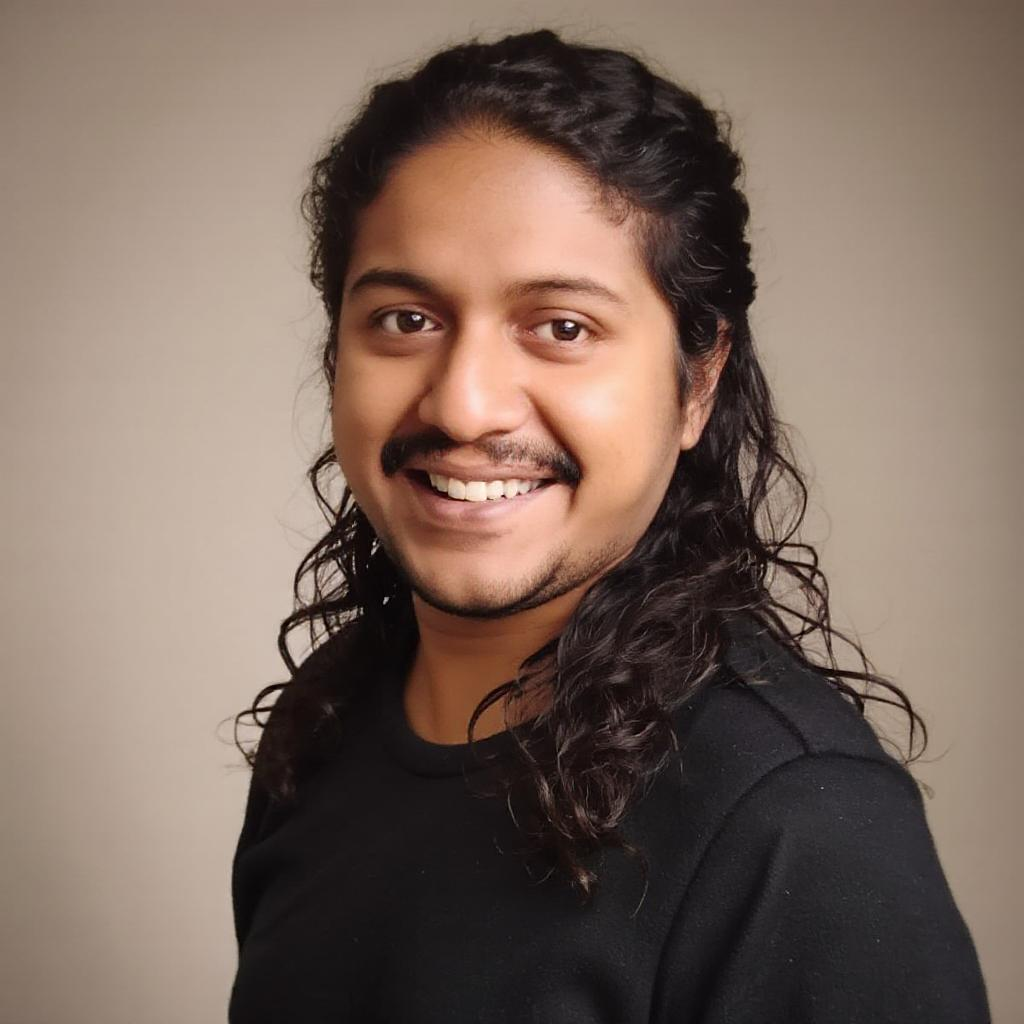

1774138510847__000002500_1.jpg


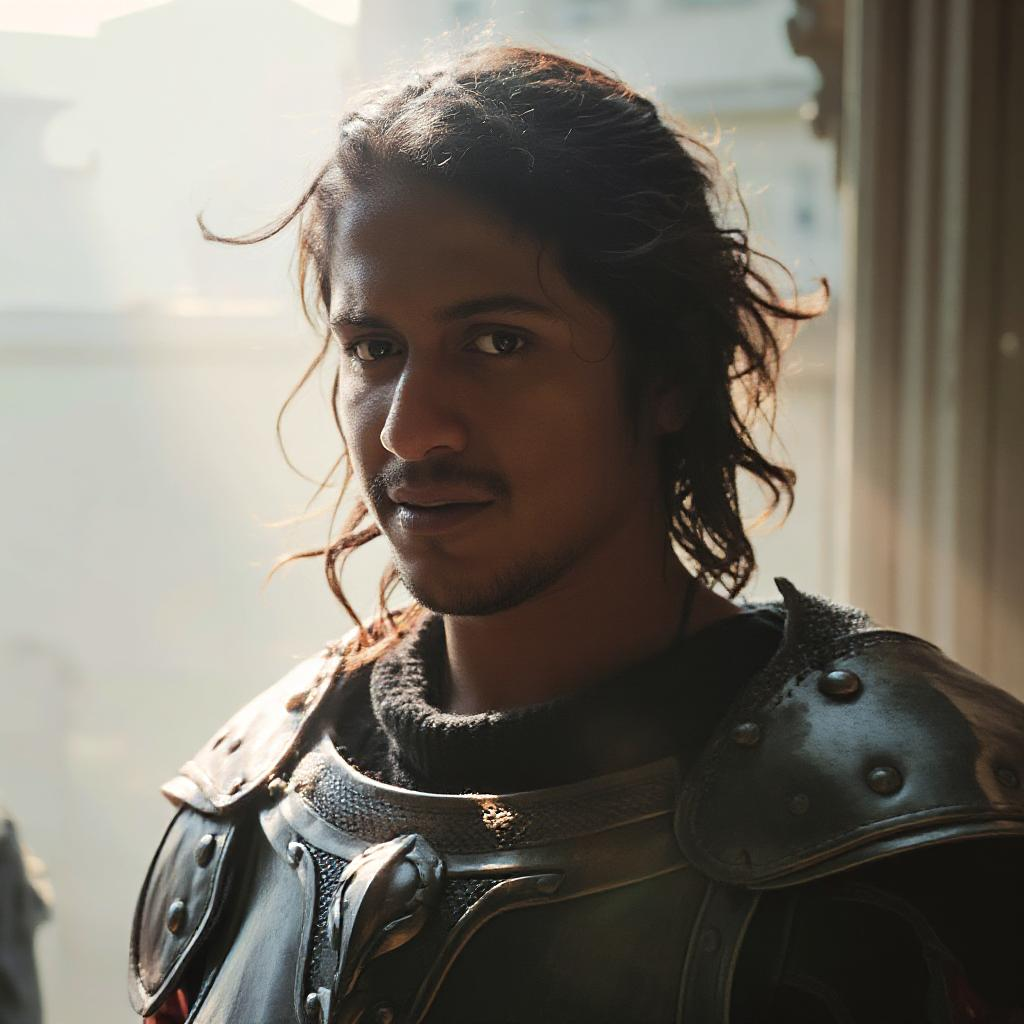

1774138515675__000002500_2.jpg


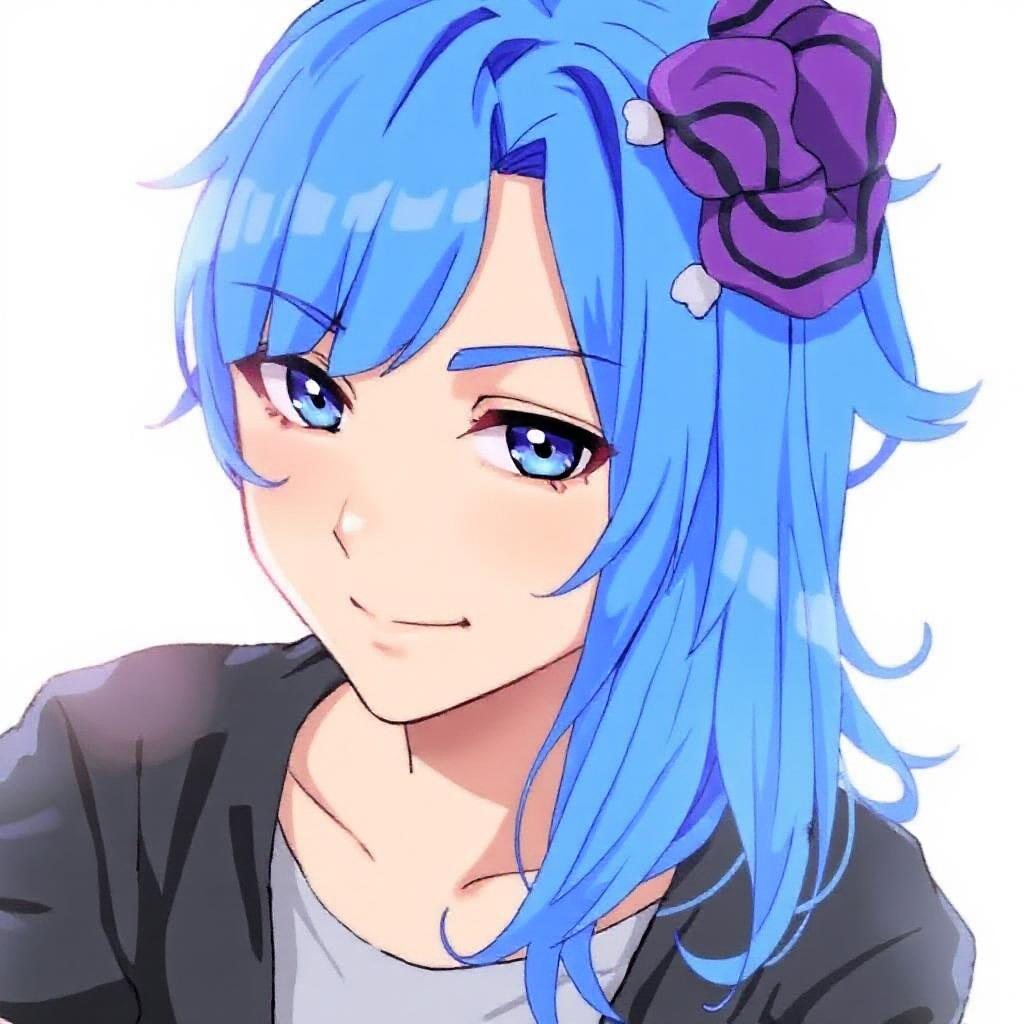

Step 000000000


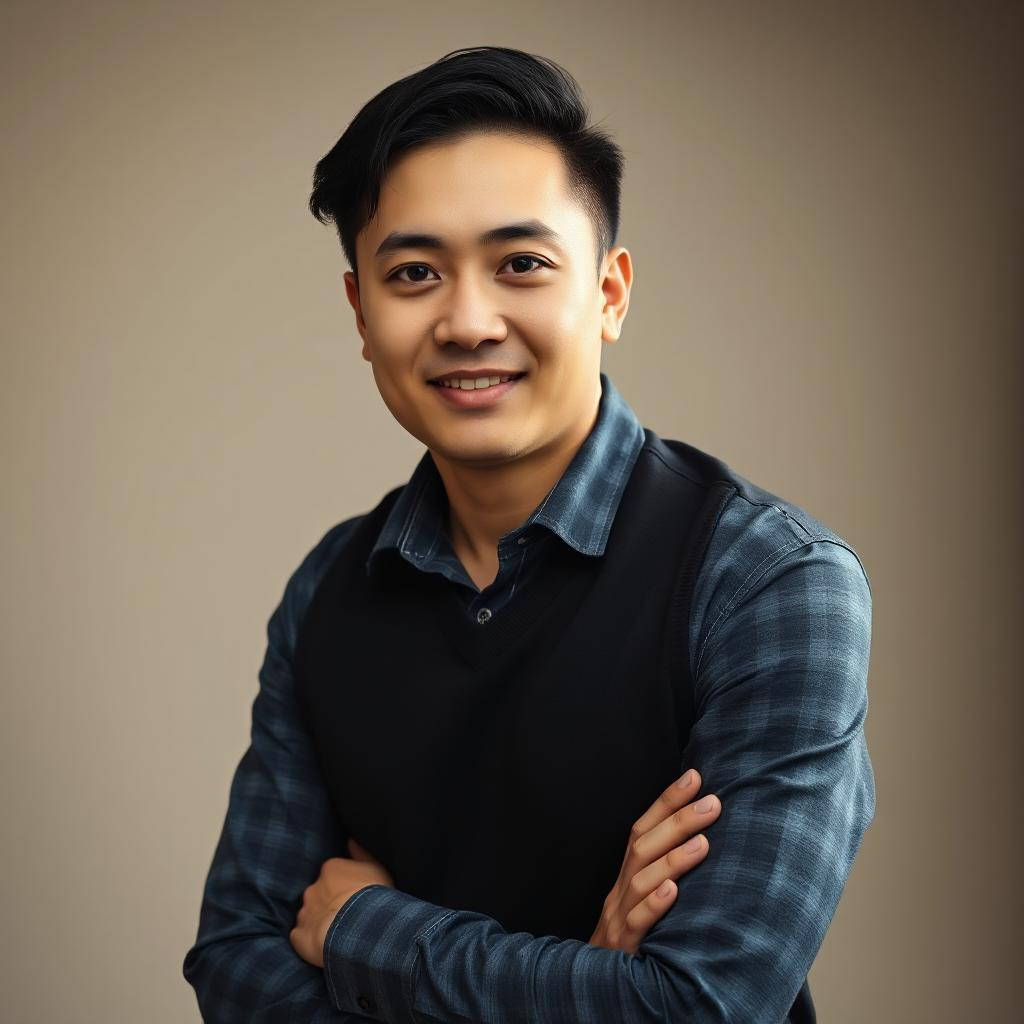

Step 000000250


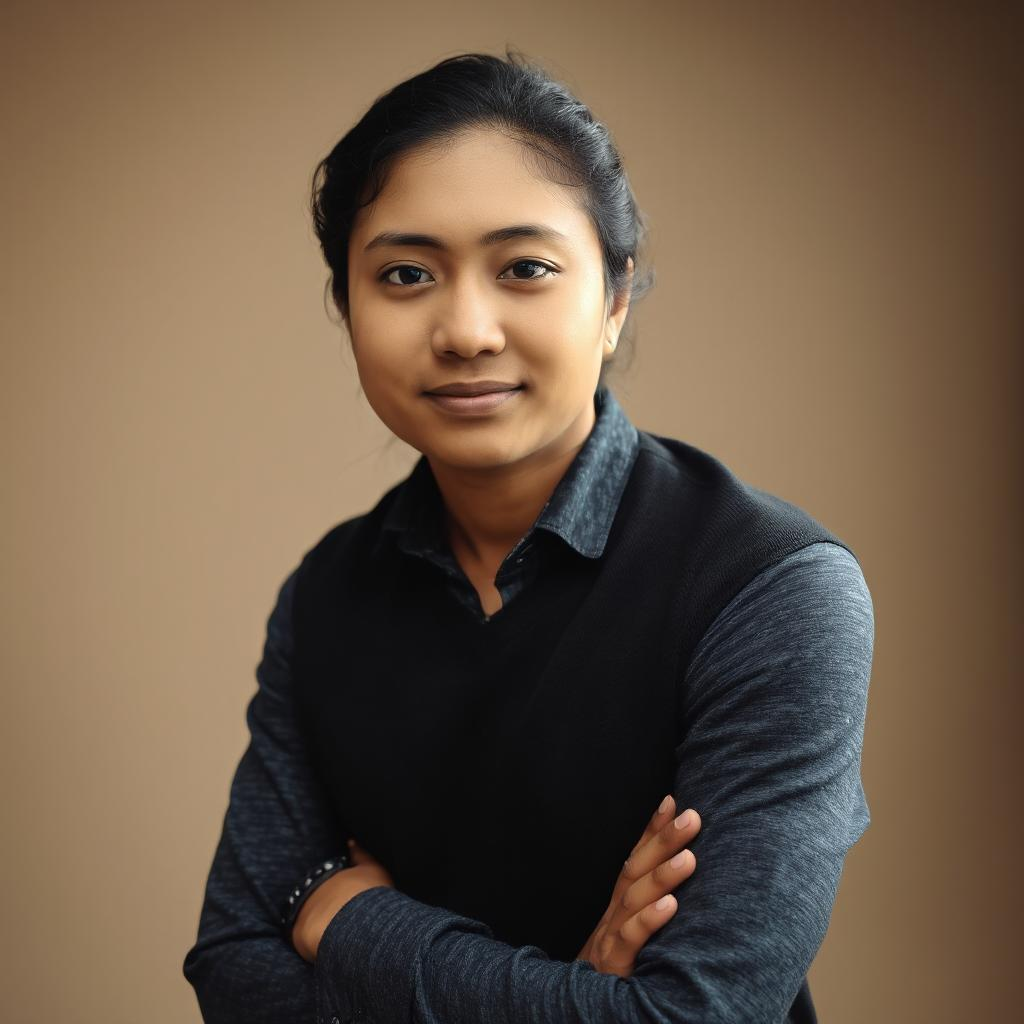

Step 000000500


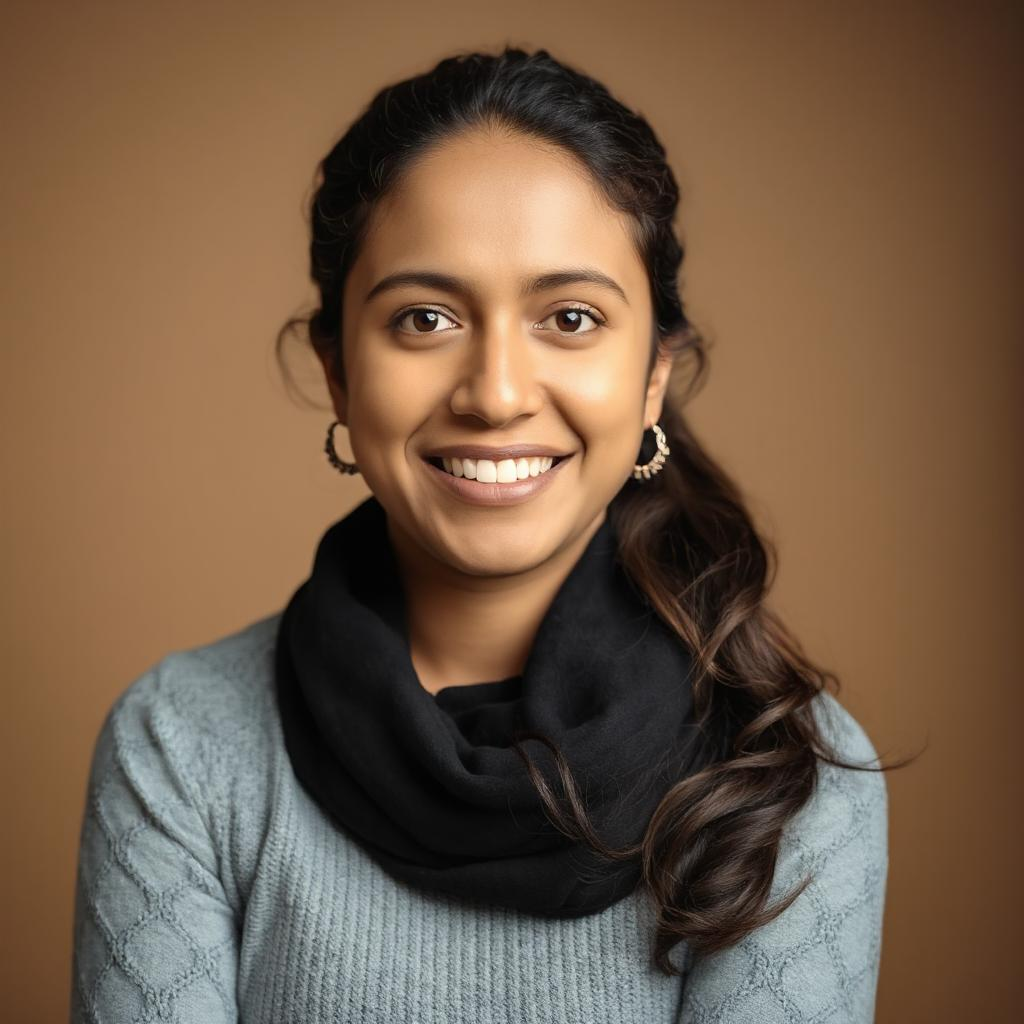

Step 000000750


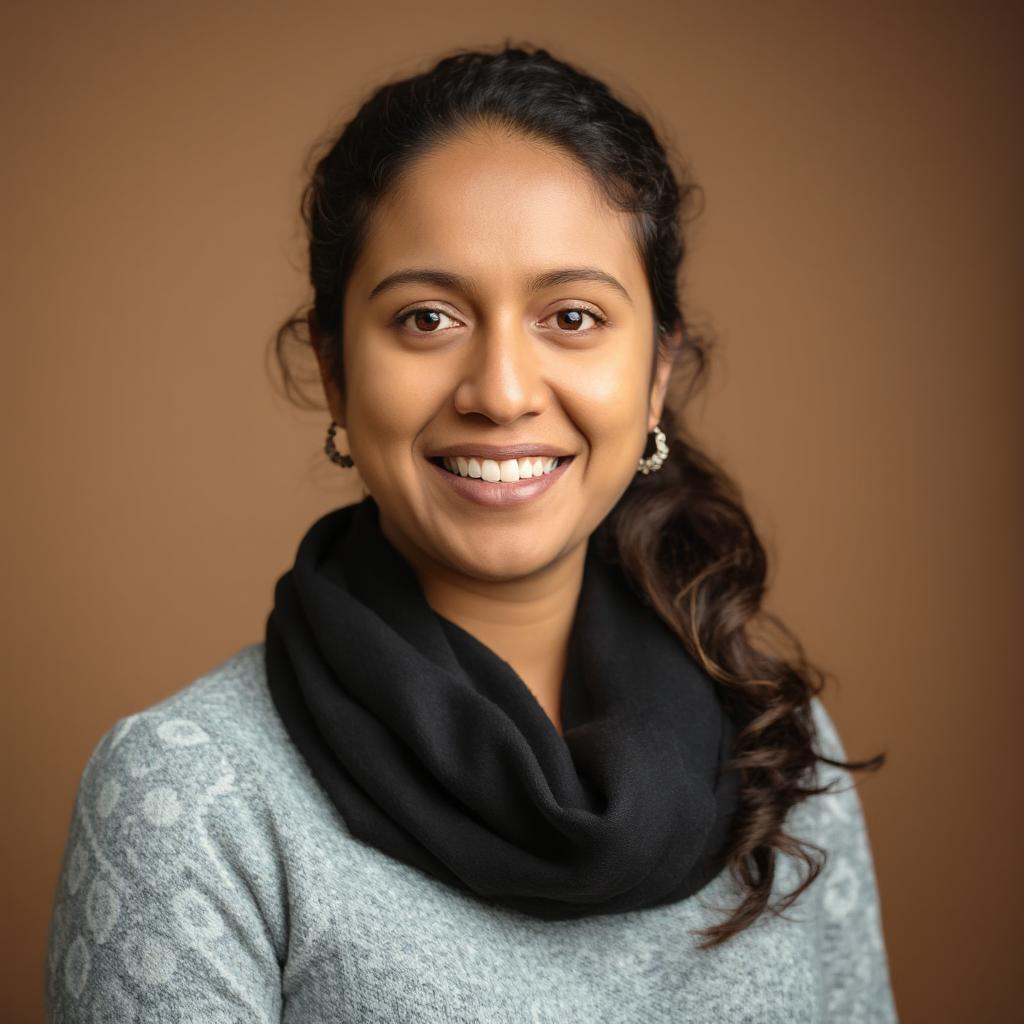

Step 000001000


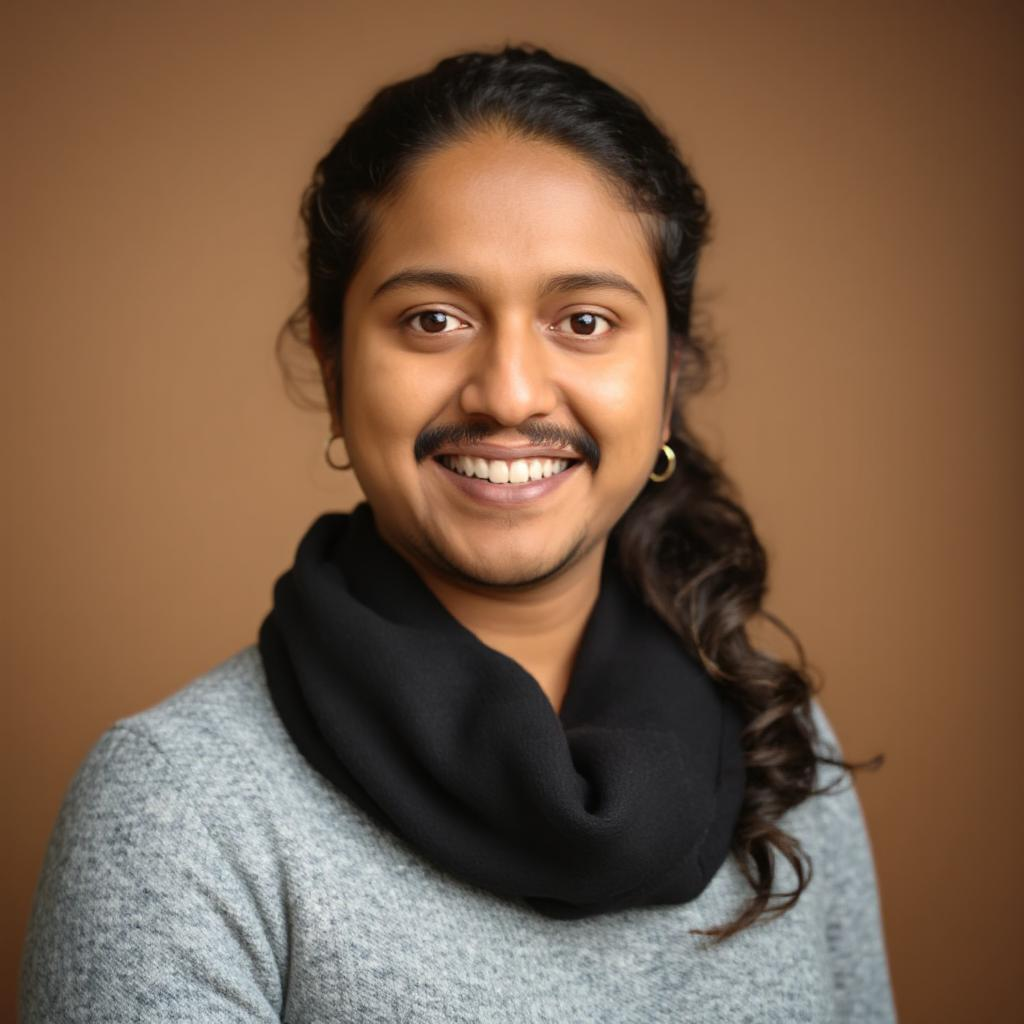

Step 000001250


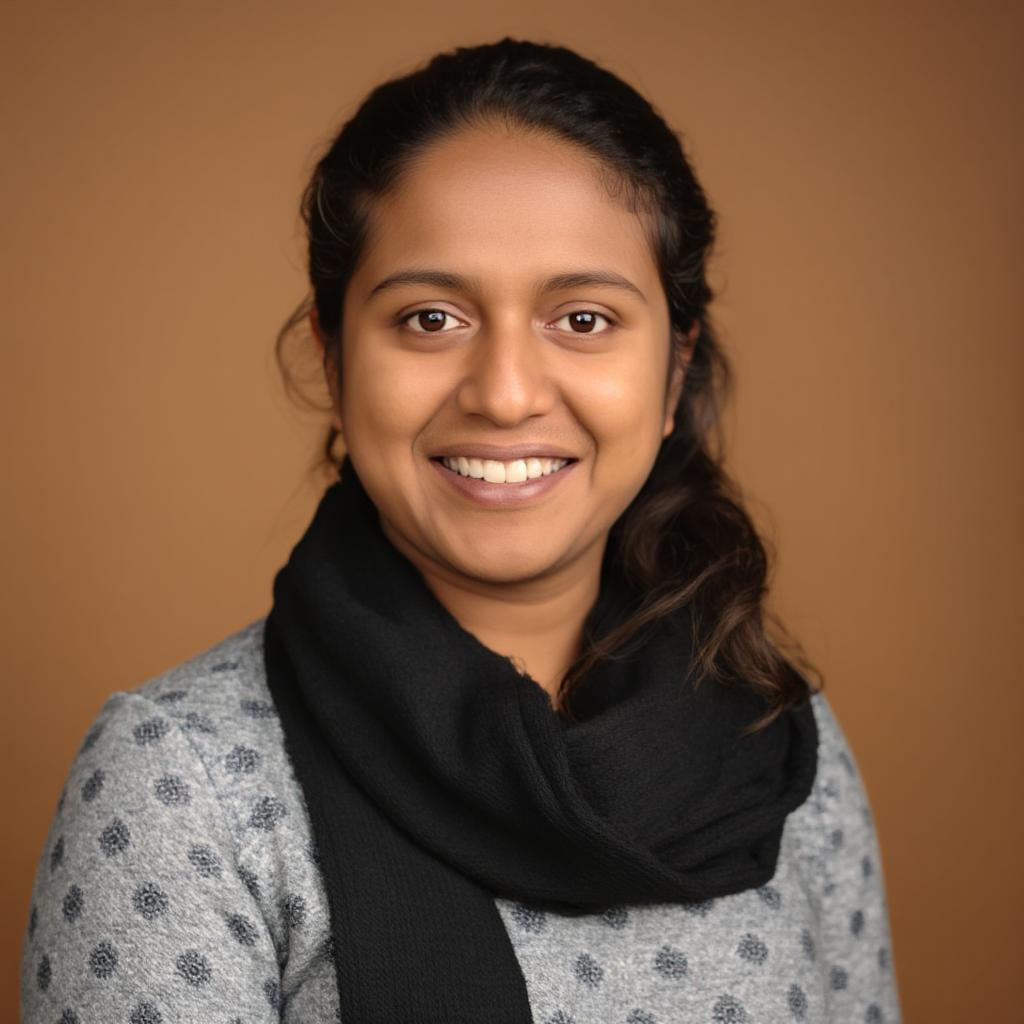

Step 000001500


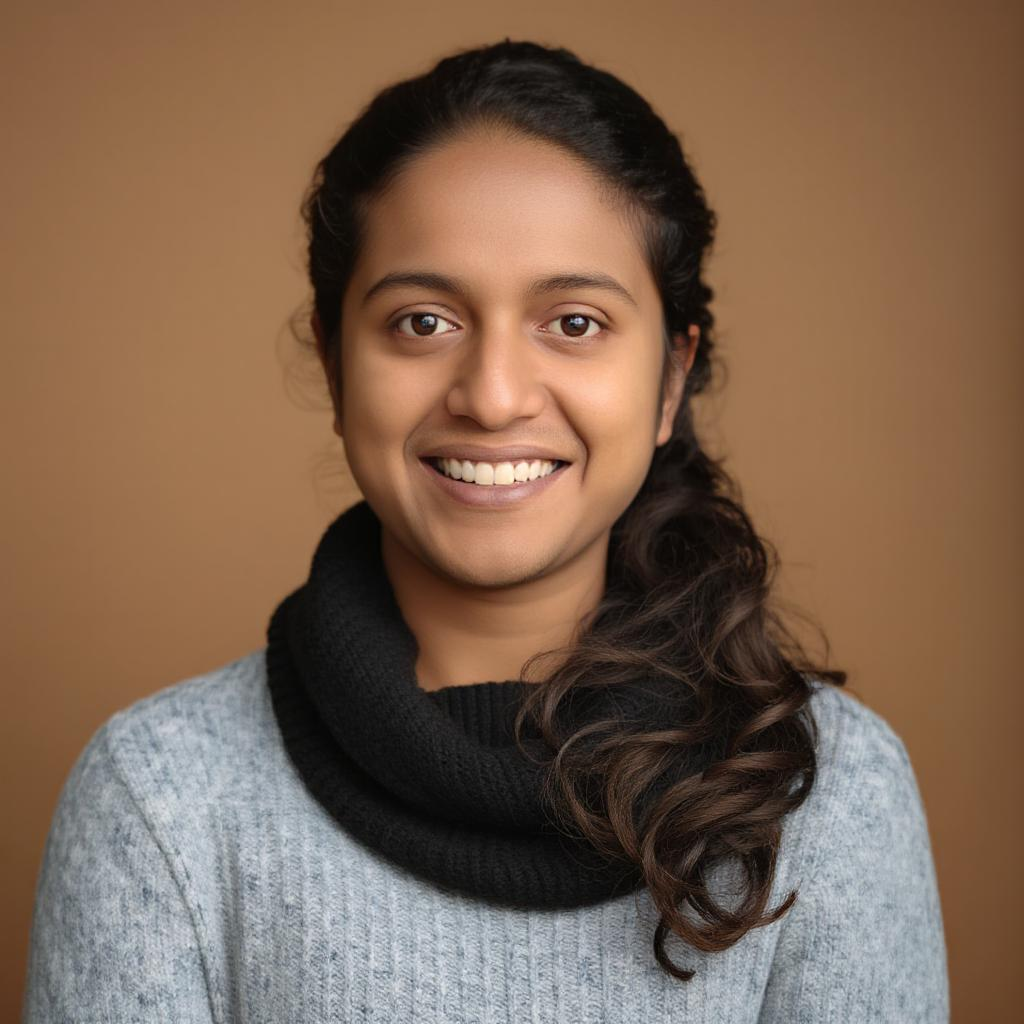

Step 000001750


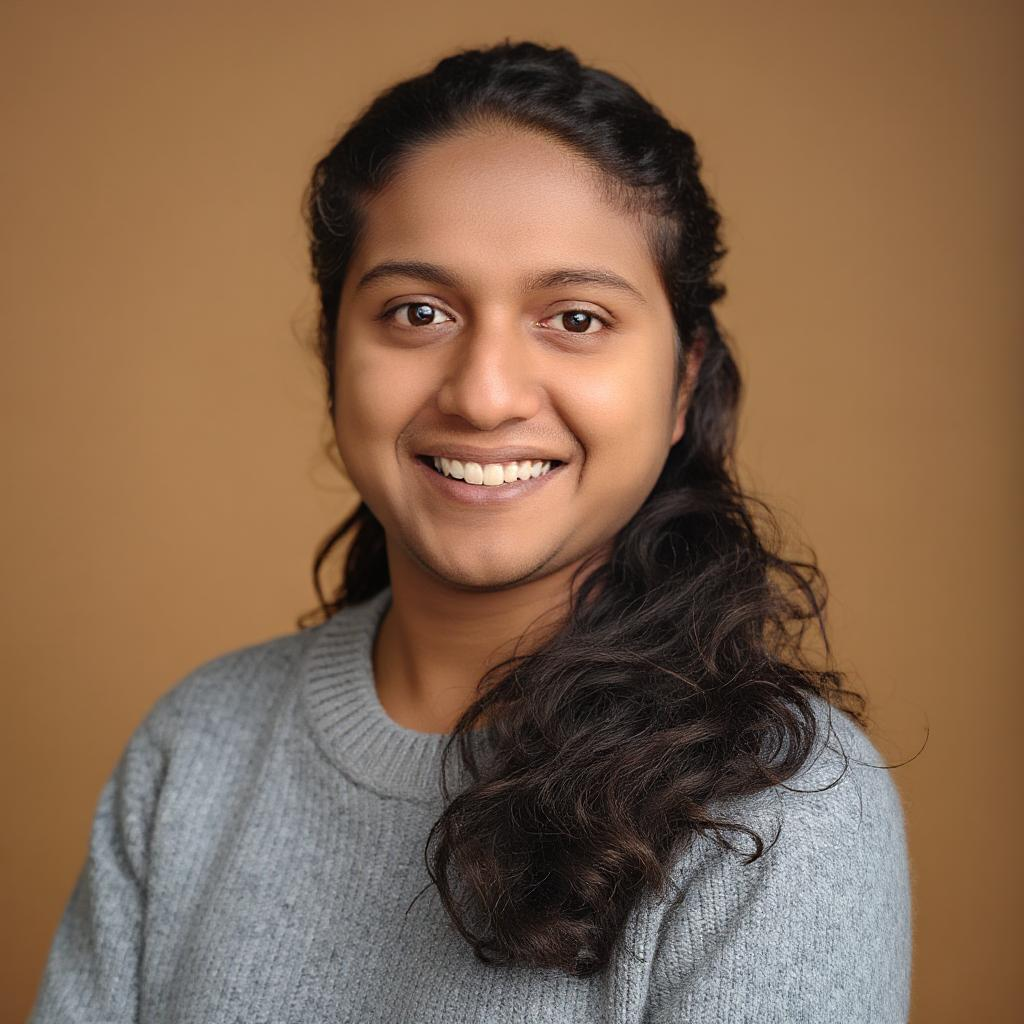

Step 000002000


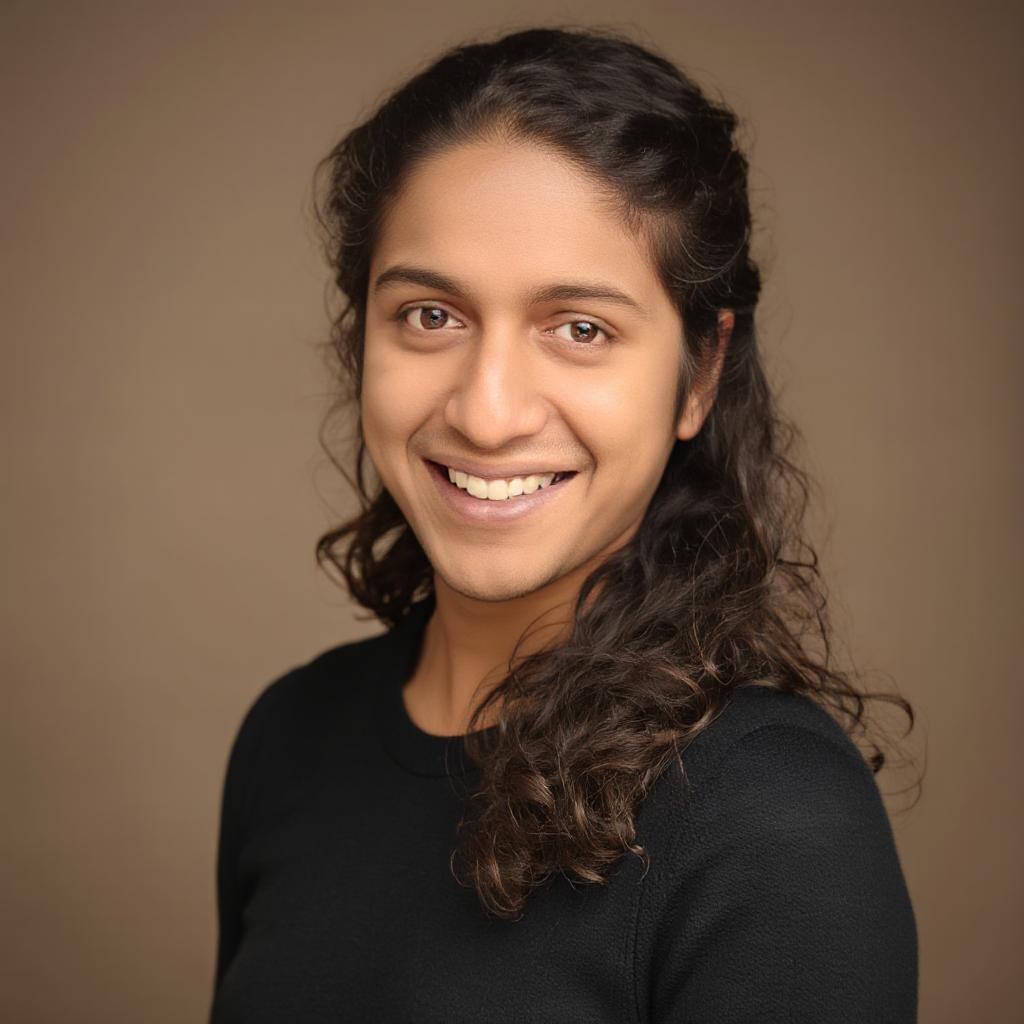

Step 000002250


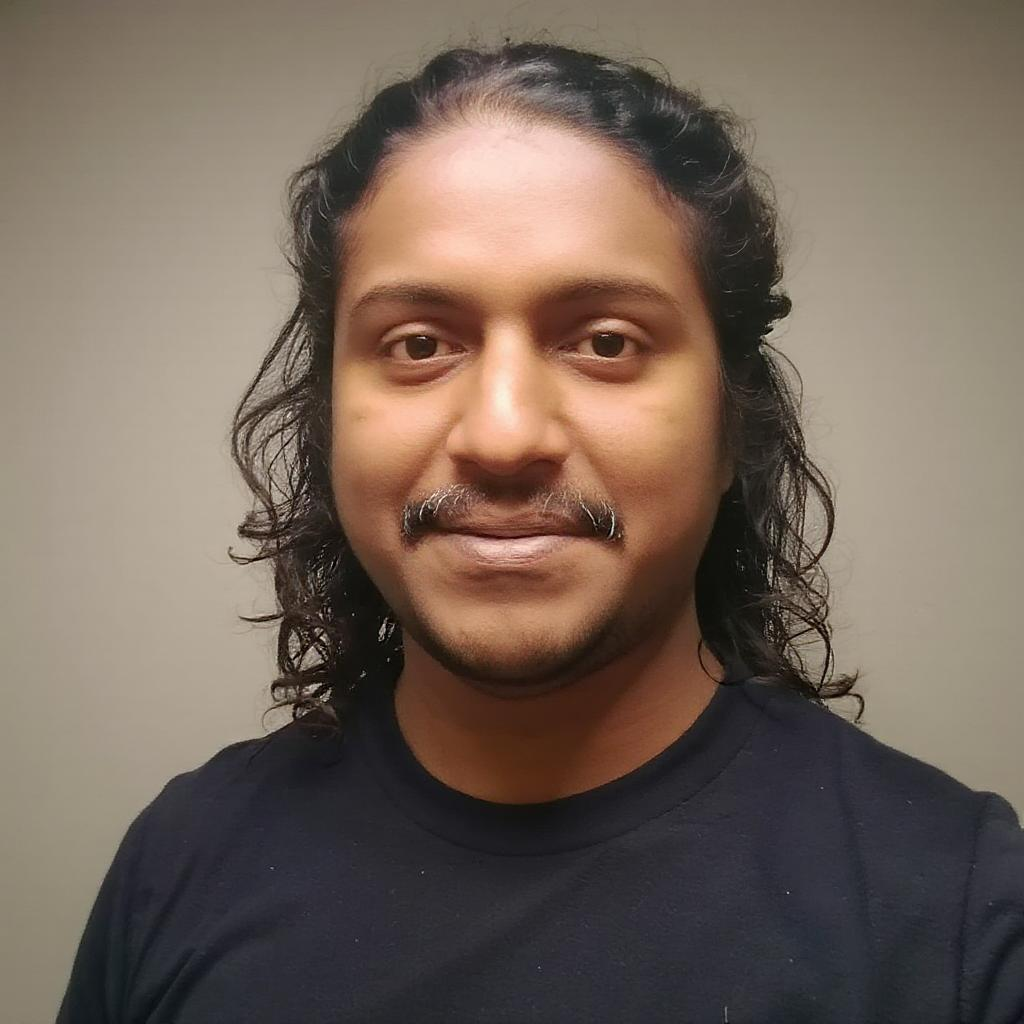

Step 000002500


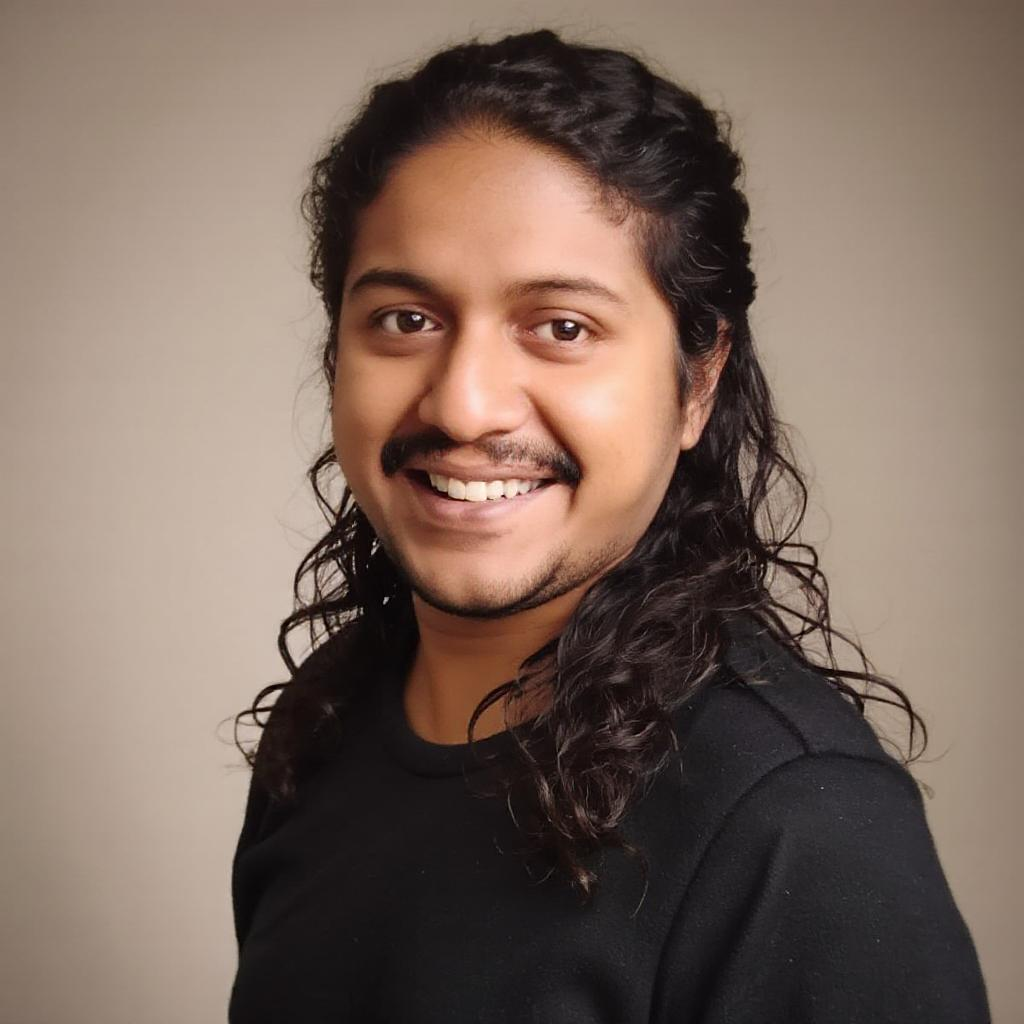

In [ ]:
from IPython.display import display, Image

samples_dir = f"{OUTPUT_DIR}/avatar_schnell_lora/samples"
final_samples = sorted(glob.glob(f"{samples_dir}/*_000002500_*.jpg"))

for img_path in final_samples:
    print(os.path.basename(img_path))
    display(Image(filename=img_path, width=512))

#You can also compare progression across steps by viewing one prompt index (e.g., _0.jpg) at different checkpoints:

# Show prompt 0 across all steps to see training progression
progression = sorted(glob.glob(f"{samples_dir}/*_0.jpg"))
for img_path in progression:
    step = os.path.basename(img_path).split("__")[1].split("_")[0]
    print(f"Step {step}")
    display(Image(filename=img_path, width=384))

In [ ]:
# List saved LoRA checkpoints
lora_files = sorted(glob.glob(f"{OUTPUT_DIR}/avatar_schnell_lora/*.safetensors"))
print("Saved LoRA files:")
for f in lora_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  {os.path.basename(f)} ({size_mb:.1f} MB)")

Saved LoRA files:
  avatar_schnell_lora.safetensors (164.0 MB)
  avatar_schnell_lora_000001000.safetensors (164.0 MB)
  avatar_schnell_lora_000001500.safetensors (164.0 MB)
  avatar_schnell_lora_000002000.safetensors (164.0 MB)


## 6. Download & Upload to Runware

Download the final `.safetensors` file, then upload to Runware:

1. Go to [Runware Model Upload](https://runware.ai/docs/image-inference/model-upload)
2. Upload the `.safetensors` file with:
   - **Architecture:** `flux1s` (Flux Schnell)
   - **Type:** LoRA
   - **Default weight:** 1.0
3. Note the **AIR identifier** Runware assigns — you'll need it for API calls

In [ ]:
# Download the final LoRA file
from google.colab import files

final_lora = lora_files[-1] if lora_files else None
if final_lora:
    print(f"Downloading: {os.path.basename(final_lora)}")
    files.download(final_lora)
else:
    print("No LoRA files found. Check training output.")

Downloading: avatar_schnell_lora_000002000.safetensors


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Optional: Push to HuggingFace
from huggingface_hub import HfApi

REPO_ID = "alphaduriendur/flux1-schnell-lora-weights"  # Change as needed

api = HfApi()
api.create_repo(REPO_ID, exist_ok=True)
api.upload_file(
    path_or_fileobj=final_lora,
    path_in_repo="pytorch_lora_weights.safetensors",
    repo_id=REPO_ID
)
print(f"Uploaded to https://huggingface.co/{REPO_ID}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ora_000002000.safetensors:  19%|#8        | 32.0MB /  172MB            

Uploaded to https://huggingface.co/alphaduriendur/flux1-schnell-lora-weights
